# PCD Assignment 02 Image Enhancement

**Name:** Ryan

**NIM:** 25/569917/PA/24023

**Course:** Pengolahan Citra Digital (Digital Image Processing)


## Objective
Implement image enhancement techniques that work across several degraded
image types: **blurred**, **dark (underexposed)**, **bright (overexposed)**,
and **low-contrast** images. For every image type we implement at least one
enhancement technique, apply it, and evaluate the result both visually and
quantitatively.

## 1. Setup

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
import os

os.makedirs("images", exist_ok=True)
plt.rcParams["figure.figsize"] = (10, 4)
np.random.seed(0)

def to_gray(img):
    if img.ndim == 3:
        return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return img

def show_pair(before, after, title_before, title_after, fname):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, im, t in zip(axes, [before, after], [title_before, title_after]):
        cmap = "gray" if im.ndim == 2 else None
        ax.imshow(im, cmap=cmap)
        ax.set_title(t)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"images/{fname}", dpi=110)
    plt.show()

def show_hist_pair(before, after, title_before, title_after, fname):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    for ax, im, t in zip(axes, [before, after], [title_before, title_after]):
        g = to_gray(im) if im.ndim == 3 else im
        ax.hist(g.ravel(), bins=256, range=(0, 255), color="steelblue")
        ax.set_title(t)
    plt.tight_layout()
    plt.savefig(f"images/{fname}", dpi=110)
    plt.show()

def metrics(img):
    g = to_gray(img).astype(np.float64)
    mean_brightness = g.mean()
    contrast_std = g.std()
    laplacian_var = cv2.Laplacian(g, cv2.CV_64F).var()  # sharpness proxy
    return dict(mean=round(mean_brightness, 2),
                std=round(contrast_std, 2),
                lap_var=round(laplacian_var, 2))

## 2. Test images

Four degraded test images are synthesised from the same base photograph
(`skimage`'s sample "astronaut" image) so that results are directly
comparable. In practice these functions work identically on any uploaded
JPG/PNG — just replace the loading cell with `cv2.imread(path)`.

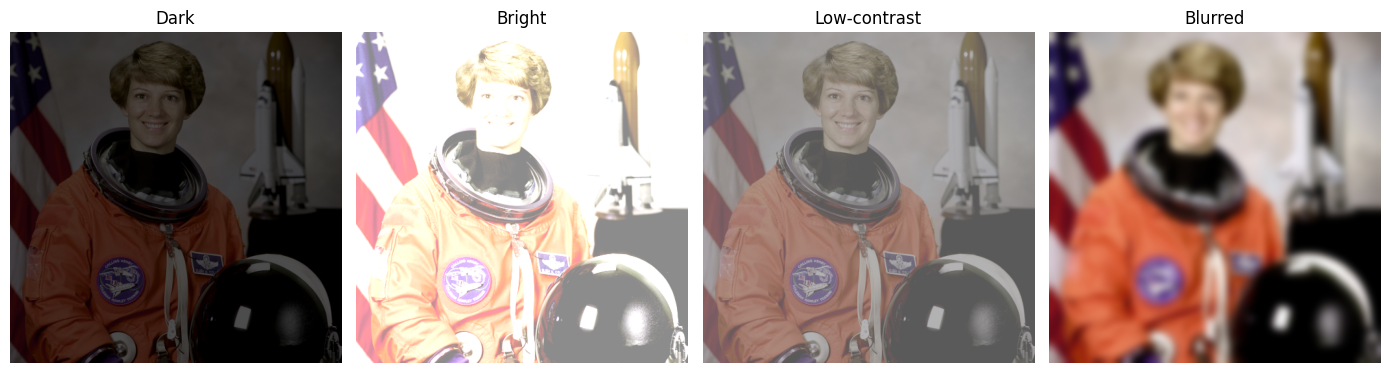

In [ ]:
base = img_as_ubyte(data.astronaut())

# Dark image: multiply down + add slight noise
dark_img = np.clip(base.astype(np.float32) * 0.30, 0, 255).astype(np.uint8)

# Bright / overexposed image: push values up towards 255
bright_img = np.clip(base.astype(np.float32) * 1.0 + 140, 0, 255).astype(np.uint8)

# Low-contrast image: compress dynamic range into a narrow mid-gray band
low_contrast_img = np.clip(base.astype(np.float32) * 0.35 + 90, 0, 255).astype(np.uint8)

# Blurred image: strong Gaussian blur
blurred_img = cv2.GaussianBlur(base, (0, 0), sigmaX=6)

cv2.imwrite("images/00_original.png", cv2.cvtColor(base, cv2.COLOR_RGB2BGR))
cv2.imwrite("images/01_dark_input.png", cv2.cvtColor(dark_img, cv2.COLOR_RGB2BGR))
cv2.imwrite("images/02_bright_input.png", cv2.cvtColor(bright_img, cv2.COLOR_RGB2BGR))
cv2.imwrite("images/03_lowcontrast_input.png", cv2.cvtColor(low_contrast_img, cv2.COLOR_RGB2BGR))
cv2.imwrite("images/04_blurred_input.png", cv2.cvtColor(blurred_img, cv2.COLOR_RGB2BGR))

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, im, t in zip(axes,
                      [dark_img, bright_img, low_contrast_img, blurred_img],
                      ["Dark", "Bright", "Low-contrast", "Blurred"]):
    ax.imshow(im); ax.set_title(t); ax.axis("off")
plt.tight_layout()
plt.savefig("images/05_all_inputs.png", dpi=110)
plt.show()

## 3. Enhancement 1 Dark image → Gamma Correction

A dark image has most pixel intensities compressed near 0. Gamma
correction with **gamma < 1** applies a power-law transform
`output = 255 * (input/255)^gamma`, which non-linearly stretches the dark
tones upward while compressing the already-bright ones, making shadow
detail visible without blowing out highlights.

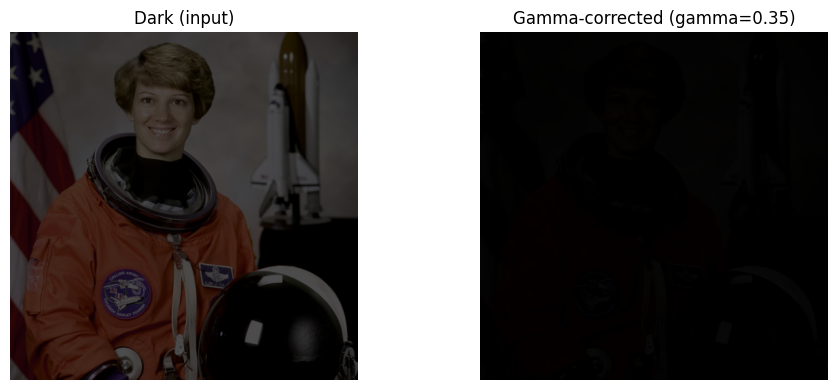

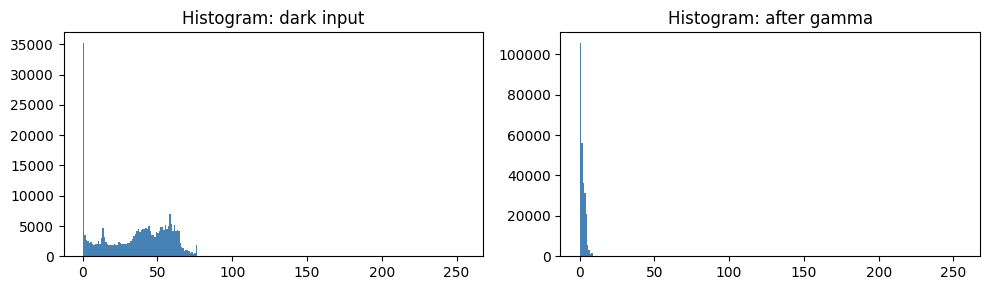

Dark input   : {'mean': np.float64(34.21), 'std': np.float64(22.47), 'lap_var': np.float64(79.23)}
Dark enhanced: {'mean': np.float64(1.44), 'std': np.float64(1.64), 'lap_var': np.float64(1.43)}


In [ ]:
def gamma_correction(img, gamma):
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(img, table)

dark_enhanced = gamma_correction(dark_img, gamma=0.35)

cv2.imwrite("images/06_dark_enhanced.png", cv2.cvtColor(dark_enhanced, cv2.COLOR_RGB2BGR))
show_pair(dark_img, dark_enhanced, "Dark (input)", "Gamma-corrected (gamma=0.35)", "07_dark_compare.png")
show_hist_pair(dark_img, dark_enhanced, "Histogram: dark input", "Histogram: after gamma", "08_dark_hist.png")

print("Dark input   :", metrics(dark_img))
print("Dark enhanced:", metrics(dark_enhanced))

## 4. Enhancement 2 Bright image → Inverse Gamma Correction

An overexposed image is the mirror problem: intensities are pushed toward
255. Using **gamma > 1** pulls bright tones back down and expands the
highlight region, recovering detail that was nearly clipped to white.

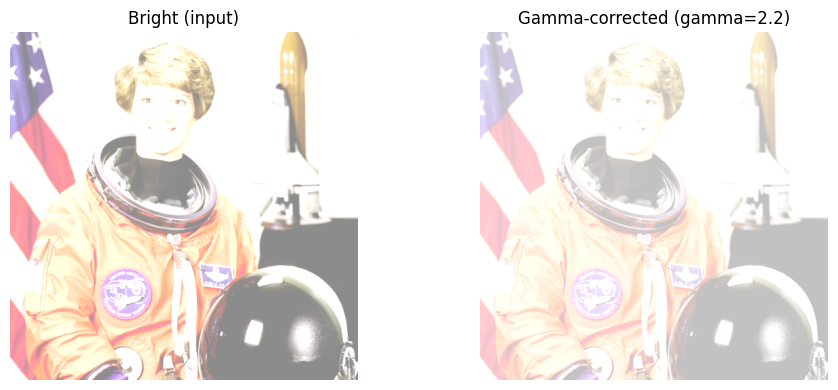

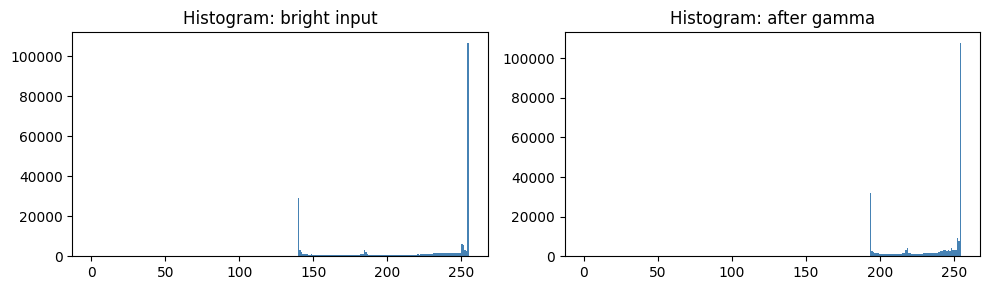

Bright input   : {'mean': np.float64(219.55), 'std': np.float64(43.87), 'lap_var': np.float64(355.25)}
Bright enhanced: {'mean': np.float64(236.55), 'std': np.float64(23.14), 'lap_var': np.float64(95.99)}


In [ ]:
bright_enhanced = gamma_correction(bright_img, gamma=2.2)

cv2.imwrite("images/09_bright_enhanced.png", cv2.cvtColor(bright_enhanced, cv2.COLOR_RGB2BGR))
show_pair(bright_img, bright_enhanced, "Bright (input)", "Gamma-corrected (gamma=2.2)", "10_bright_compare.png")
show_hist_pair(bright_img, bright_enhanced, "Histogram: bright input", "Histogram: after gamma", "11_bright_hist.png")

print("Bright input   :", metrics(bright_img))
print("Bright enhanced:", metrics(bright_enhanced))

## 5. Enhancement 3 Low-contrast image → CLAHE

A low-contrast image has its histogram squeezed into a narrow band.
**CLAHE (Contrast Limited Adaptive Histogram Equalization)** is applied on
the L-channel of the LAB color space so contrast is boosted locally
(per tile) without amplifying noise or distorting color, which is a
common problem with global histogram equalization.

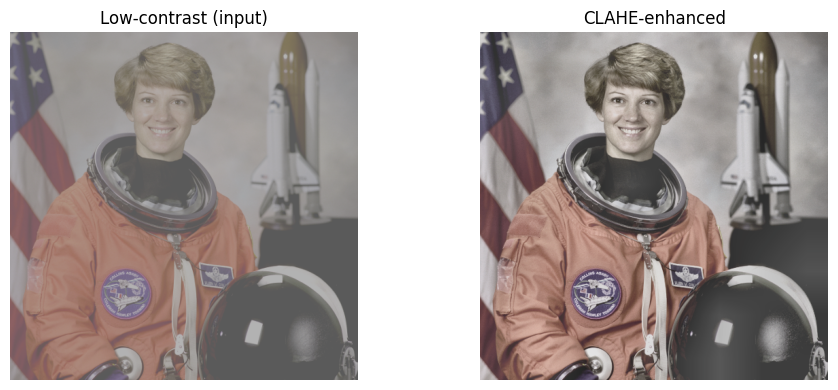

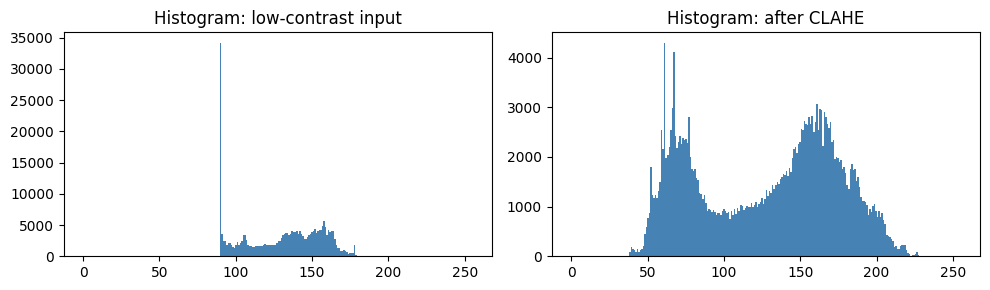

Low-contrast input   : {'mean': np.float64(129.96), 'std': np.float64(26.21), 'lap_var': np.float64(107.03)}
Low-contrast enhanced: {'mean': np.float64(128.08), 'std': np.float64(46.63), 'lap_var': np.float64(561.39)}


In [ ]:
def clahe_enhance(img, clip_limit=2.5, tile_grid=(8, 8)):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    l_eq = clahe.apply(l)
    merged = cv2.merge((l_eq, a, b))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

lowc_enhanced = clahe_enhance(low_contrast_img)

cv2.imwrite("images/12_lowcontrast_enhanced.png", cv2.cvtColor(lowc_enhanced, cv2.COLOR_RGB2BGR))
show_pair(low_contrast_img, lowc_enhanced, "Low-contrast (input)", "CLAHE-enhanced", "13_lowcontrast_compare.png")
show_hist_pair(low_contrast_img, lowc_enhanced, "Histogram: low-contrast input", "Histogram: after CLAHE", "14_lowcontrast_hist.png")

print("Low-contrast input   :", metrics(low_contrast_img))
print("Low-contrast enhanced:", metrics(lowc_enhanced))

## 6. Enhancement 4 Blurred image → Unsharp Masking

Blur removes high-frequency (edge) content. **Unsharp masking** creates a
blurred copy of the image, subtracts it from the original to isolate the
high-frequency edge detail, and adds that detail back with a gain factor,
amplifying edges without amplifying overall brightness.

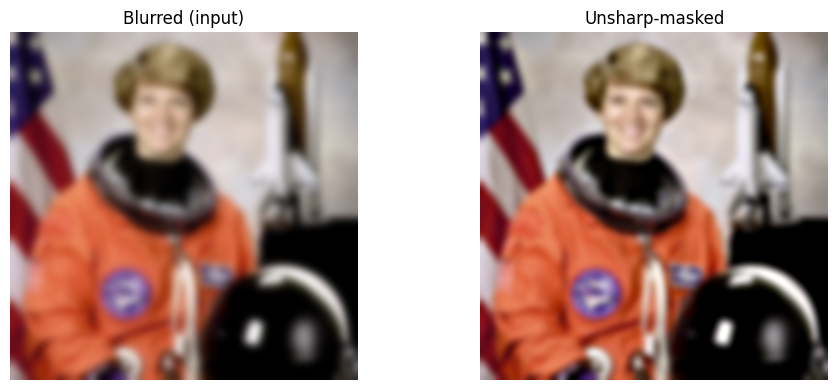

Blurred input   : {'mean': np.float64(115.4), 'std': np.float64(65.22), 'lap_var': np.float64(2.1)}
Blurred enhanced: {'mean': np.float64(115.5), 'std': np.float64(68.77), 'lap_var': np.float64(10.89)}


In [ ]:
def unsharp_mask(img, sigma=3, amount=1.8, threshold=0):
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    sharpened = cv2.addWeighted(img, 1 + amount, blurred, -amount, 0)
    if threshold > 0:
        low_contrast_mask = np.abs(img.astype(int) - blurred.astype(int)) < threshold
        np.copyto(sharpened, img, where=low_contrast_mask)
    return sharpened

blurred_enhanced = unsharp_mask(blurred_img, sigma=4, amount=2.0)

cv2.imwrite("images/15_blurred_enhanced.png", cv2.cvtColor(blurred_enhanced, cv2.COLOR_RGB2BGR))
show_pair(blurred_img, blurred_enhanced, "Blurred (input)", "Unsharp-masked", "16_blurred_compare.png")

print("Blurred input   :", metrics(blurred_img))
print("Blurred enhanced:", metrics(blurred_enhanced))

## 7. Summary table

In [ ]:
import pandas as pd

rows = [
    ("Dark",         "Gamma correction (γ=0.35)", metrics(dark_img),          metrics(dark_enhanced)),
    ("Bright",       "Gamma correction (γ=2.2)",  metrics(bright_img),        metrics(bright_enhanced)),
    ("Low-contrast", "CLAHE",                     metrics(low_contrast_img),  metrics(lowc_enhanced)),
    ("Blurred",      "Unsharp masking",           metrics(blurred_img),       metrics(blurred_enhanced)),
]

table = pd.DataFrame([{
    "Image type": r[0],
    "Technique": r[1],
    "Mean (before→after)": f"{r[2]['mean']} → {r[3]['mean']}",
    "Std/contrast (before→after)": f"{r[2]['std']} → {r[3]['std']}",
    "Laplacian var/sharpness (before→after)": f"{r[2]['lap_var']} → {r[3]['lap_var']}",
} for r in rows])

table

,Image type,Technique,Mean (before→after),Std/contrast (before→after),Laplacian var/sharpness (before→after)
0,Dark,Gamma correction (γ=0.35),34.21 → 1.44,22.47 → 1.64,79.23 → 1.43
1,Bright,Gamma correction (γ=2.2),219.55 → 236.55,43.87 → 23.14,355.25 → 95.99
2,Low-contrast,CLAHE,129.96 → 128.08,26.21 → 46.63,107.03 → 561.39
3,Blurred,Unsharp masking,115.4 → 115.5,65.22 → 68.77,2.1 → 10.89
